In [23]:
import pickle
import os
import matplotlib.pyplot as plt



file_path = os.path.join(
    ".",
    "Post_Filtering_trade_off_result_generated.pkl"
)

with open(file_path, "rb") as f:
    trade_off = pickle.load(f)


file_path = "/home/ec2-user/hybrid_hardness/over_optimism_experiment/Post_Filtering_trade_off_result_semi.pkl"

with open(file_path, "rb") as f:
    trade_off_semi = pickle.load(f)

trade_off = trade_off | trade_off_semi


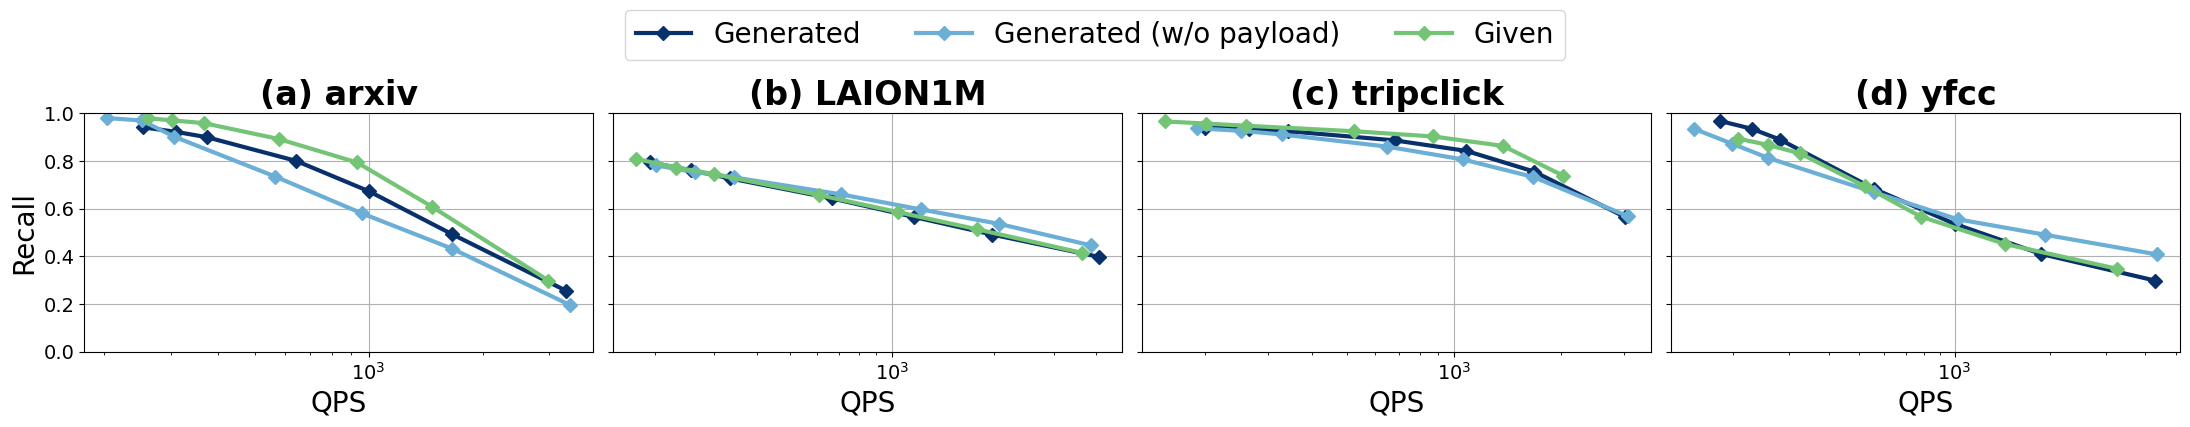

In [26]:
import matplotlib.pyplot as plt

# =================================================
# Fontsize 옵션 (여기만 만지면 전체 조절됨)
# =================================================
FS_TITLE   = 18   # 전체 figure title
FS_SUBTITLE = 24  # subplot title
FS_LABEL   = 20   # axis label
FS_TICK    = 14   # tick label
FS_LEGEND  = 20   # legend text

# =================================================
# subplot 대상 dataset
# =================================================
datasets = ["arxiv", "LAION1M", "tripclick", "yfcc"]
dataset_names = ["(a) arxiv", "(b) LAION1M", "(c) tripclick", "(d) yfcc"]
# =================================================
# 색상 매핑
# =================================================
COLOR_MAP = {
    "generated": "#08306B",
    "generated_wo_payload": "#6BAED6",
    "given": "#74C476",
}

LABEL_MAP = {
    "generated": "Generated",
    "generated_wo_payload": "Generated (w/o payload)",
    "given": "Given",
}

# =================================================
# Figure
# =================================================
fig, axes = plt.subplots(1, 4, figsize=(22, 4), sharey=True)

# =================================================
# 각 dataset별 subplot
# =================================================
for ax, dataset, dataset_name in zip(axes[:4], datasets, dataset_names):

    for dataset_key, stats_dict in trade_off.items():
        if not dataset_key.startswith(dataset):
            continue

        K_ns = sorted(stats_dict.keys())
        qps_values = [stats_dict[k]["qps"] for k in K_ns]
        recall_values = [stats_dict[k]["avg_recall"] for k in K_ns]

        if dataset_key.endswith("_generated_wo_payload"):
            style = "generated_wo_payload"
        elif dataset_key.endswith("_generated"):
            style = "generated"
        else:
            style = "given"

        ax.plot(
            qps_values,
            recall_values,
            marker="D",
            markersize=7,
            linewidth=3.0,
            color=COLOR_MAP[style],
            label=LABEL_MAP[style],
        )

    ax.set_title(dataset_name, fontsize=FS_SUBTITLE, fontweight="bold")
    ax.set_xscale("log")
    ax.set_ylim(0.0, 1.0)
    ax.grid(True)

    ax.set_xlabel("QPS", fontsize=FS_LABEL)
    ax.tick_params(axis="both", labelsize=FS_TICK)

# =================================================
# 공통 Y label
# =================================================
axes[0].set_ylabel("Recall", fontsize=FS_LABEL)

# =================================================
# 상단 Legend (1 row)
# =================================================
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    fontsize=FS_LEGEND,
    frameon=True,
    bbox_to_anchor=(0.5, 1.09),
)


# =================================================
# Layout
# =================================================
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()
